In [39]:
pip install seaborn matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Configuración global de Seaborn
sns.set_theme(
style='whitegrid',
palette='muted',
font_scale=1.2
)
# Carga del dataset
df = pd.read_csv('cafeteria_universitaria_s8.csv')

In [2]:
df

,facultad,turno,dia_semana,tipo_pedido,metodo_pago,nivel_academico,semana_mes,gasto_total,tiempo_espera_min,calificacion_servicio,items_pedido,propina_porcentaje
0,Ciencias,Mañana,Jueves,Almuerzo,Débito,Postgrado,1,4.28,8.6,4.8,3,7.7
1,Ciencias,Mañana,Jueves,Almuerzo,QR,Postgrado,2,4.98,9.0,3.9,3,13.6
2,Ciencias,Mañana,Jueves,Snack,Débito,Postgrado,2,3.42,10.7,3.3,1,12.2
3,Ciencias,Mañana,Jueves,Almuerzo,Débito,Postgrado,2,3.64,9.5,4.0,1,5.3
4,Ciencias,Mañana,Jueves,Bebida,Débito,Postgrado,3,1.17,5.7,4.8,2,7.6
...,...,...,...,...,...,...,...,...,...,...,...,...
295,Ingeniería,Tarde,Viernes,Bebida,Débito,Pregrado,3,1.80,13.0,4.8,6,4.4
296,Ingeniería,Tarde,Viernes,Bebida,Débito,Postgrado,3,2.24,10.7,4.1,1,9.3
297,Ingeniería,Tarde,Viernes,Almuerzo,Efectivo,Pregrado,3,4.32,15.7,3.7,1,5.1
298,Ingeniería,Tarde,Viernes,Bebida,Débito,Pregrado,1,2.23,11.3,3.9,1,5.8


<Axes: >

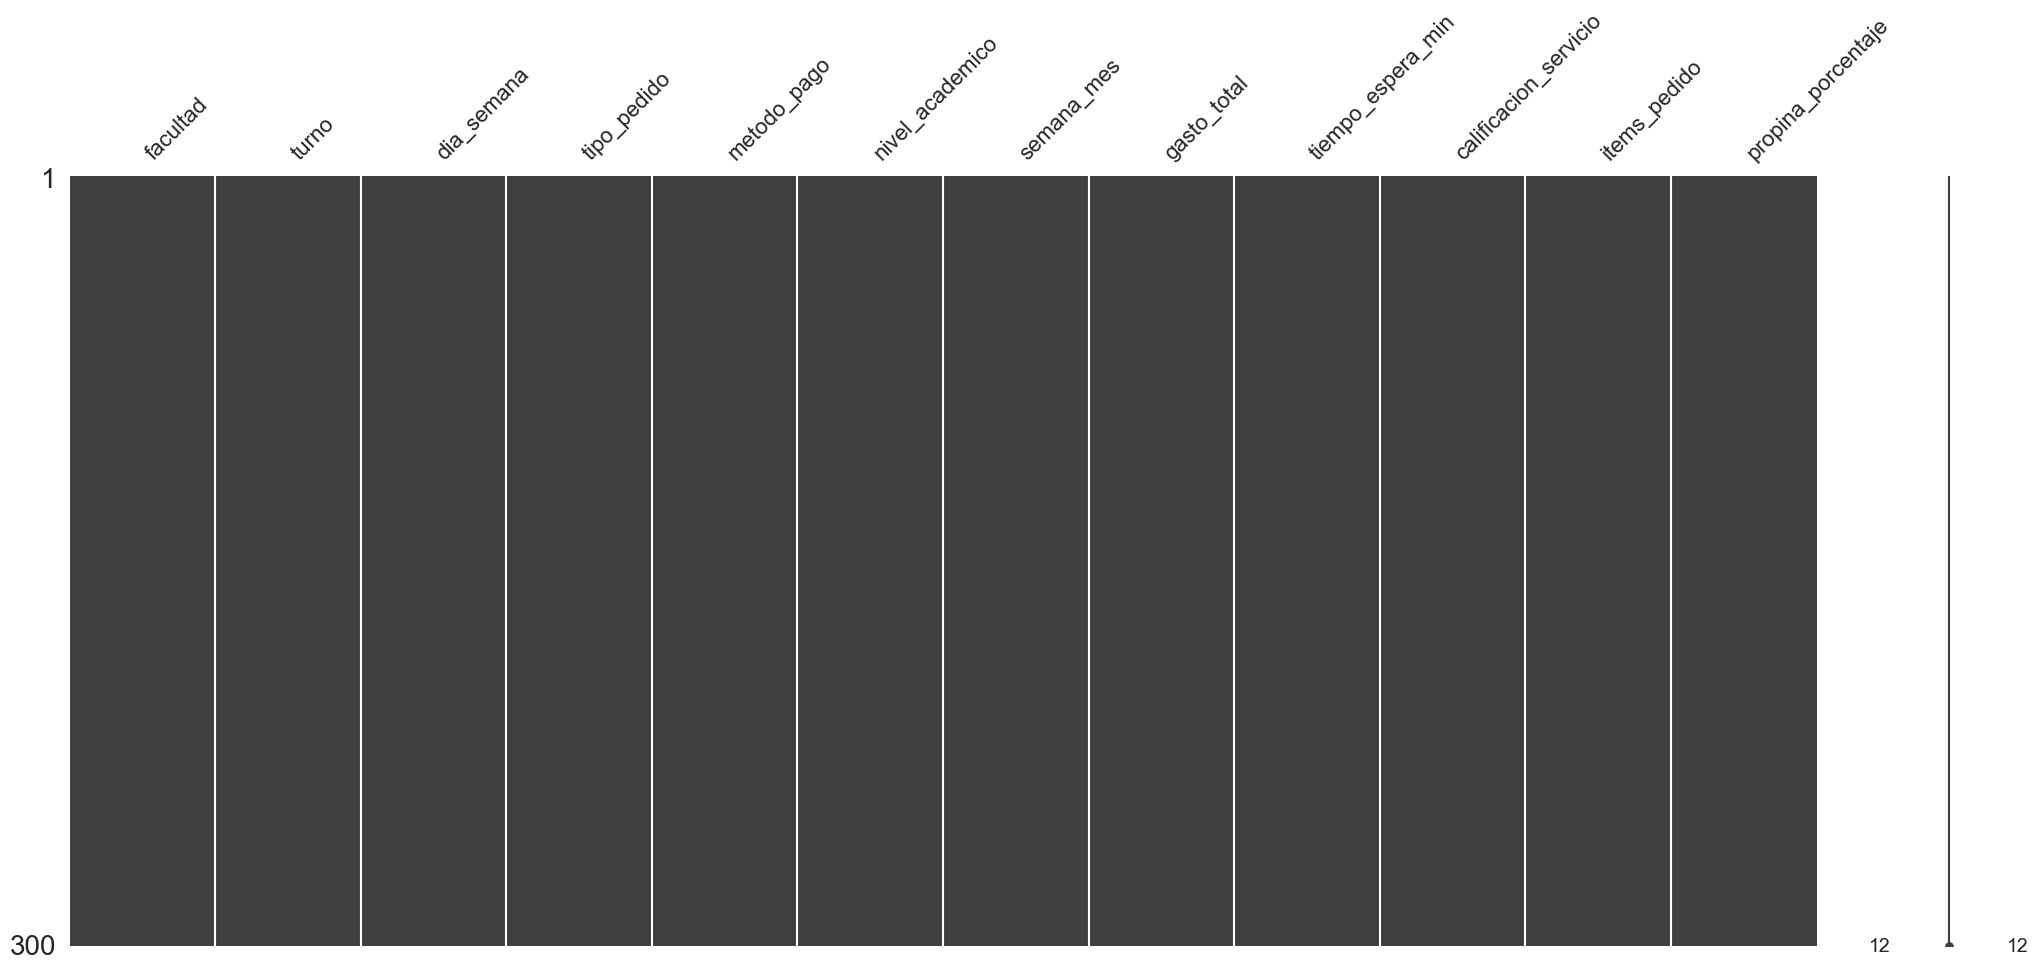

In [7]:
import missingno as msno
msno.matrix(df)

In [3]:
Límite inferior = Q1 - 1.5 × IQR
Límite superior = Q3 + 1.5 × IQR
IQR = Q3 - Q1 (Rango Intercuartílico)

SyntaxError: invalid character '×' (U+00D7) (1641329896.py, line 1)

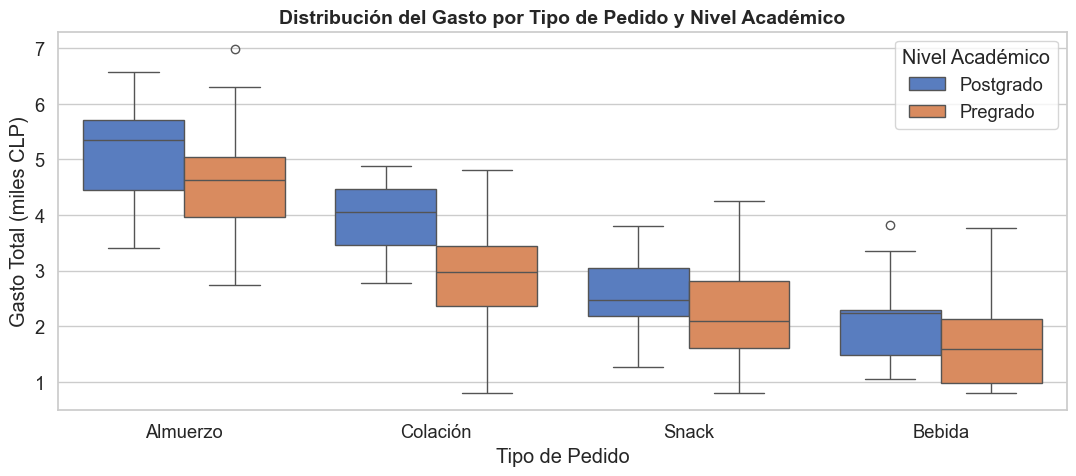

In [10]:
#Ejercicio 1
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
data=df,
x='tipo_pedido',
y='gasto_total',
hue='nivel_academico',
palette='muted',
order=['Almuerzo', 'Colación', 'Snack', 'Bebida'],
ax=ax
)
ax.set_title('Distribución del Gasto por Tipo de Pedido y Nivel Académico',
fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Pedido')
ax.set_ylabel('Gasto Total (miles CLP)')
ax.legend(title='Nivel Académico', loc='upper right')
plt.tight_layout()
plt.show(True)

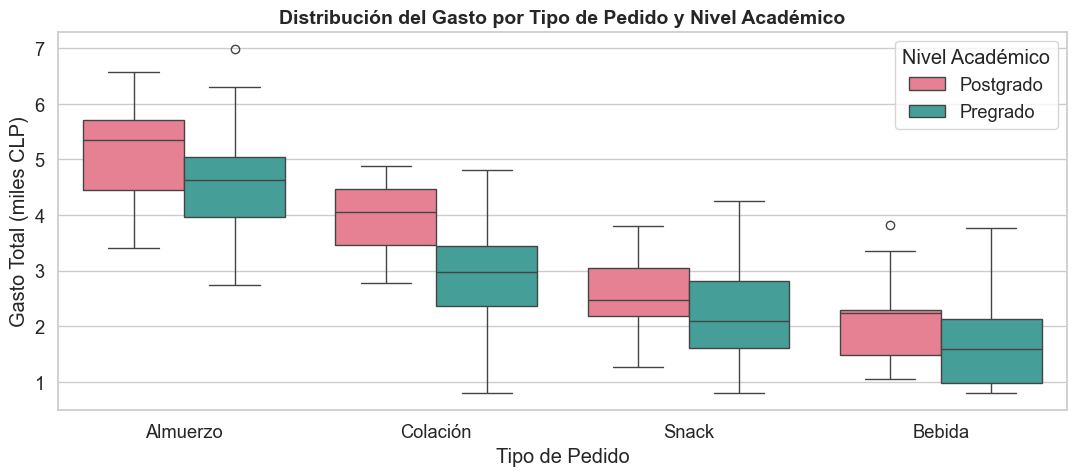

In [45]:
#Ejercicio 1 (modificable para dar resultados de la seccion de observacion
import seaborn as sns
fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
data=df,
x='tipo_pedido',
y='gasto_total',
hue='nivel_academico',
order=['Almuerzo', 'Colación', 'Snack', 'Bebida'],
ax=ax,
palette = 'husl'
)
ax.set_title('Distribución del Gasto por Tipo de Pedido y Nivel Académico',
fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Pedido')
ax.set_ylabel('Gasto Total (miles CLP)')
ax.legend(title='Nivel Académico', loc='upper right')
plt.tight_layout()
plt.show(True)

# Observaciones
1. Genera un segundo gráfico
2. Cambian las figuras de del gráfico siendo un tipo de trapecio
3. Cambia el ancho de las figuras asociadas.
4. Cambia la orientación siendo horizontal o vertical
5. Usa una paleta de colores al gráfico siendo entre un rosado y verde.

# Seccion Analisis
1. Visiblemente almuerzo representa la mayor variabilidad respecto al gráfico, teniendo un mayor rango intercuartilico.
2. Se observan outlayers en el gráfico tanto en la categoría de almuerzo, como en bebida.
3. Si existe, siendo los de posgrado los que gastan mucho más que los de pregrado según el gráafico observado visualmente.

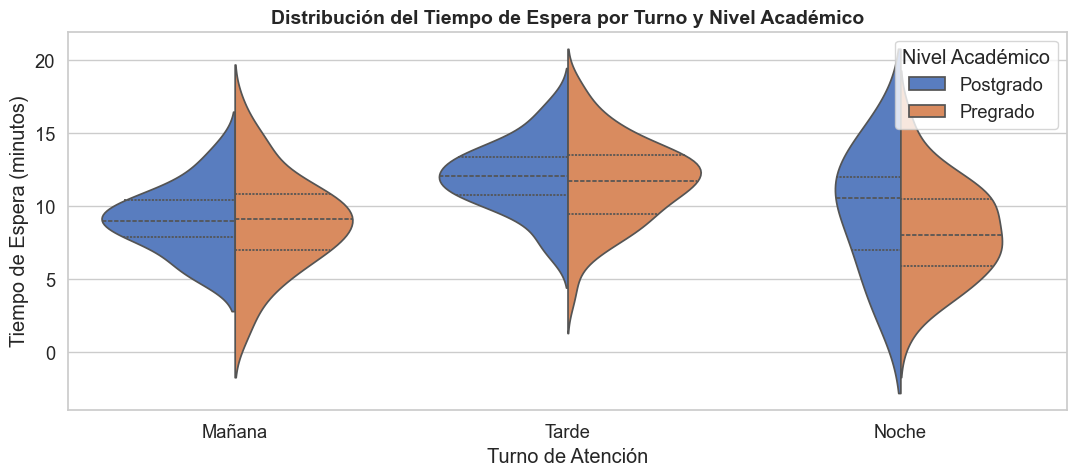

In [30]:
#Ejercicio 2
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot( 
    data=df,
    x='turno',
    y='tiempo_espera_min',
    hue='nivel_academico',
    split=True,
    inner='quartile', 
    palette='muted',
    order=['Mañana', 'Tarde', 'Noche'],
    ax=ax
)
ax.set_title('Distribución del Tiempo de Espera por Turno y Nivel Académico',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Turno de Atención')
ax.set_ylabel('Tiempo de Espera (minutos)')
ax.legend(title='Nivel Académico')
plt.tight_layout()
plt.show()

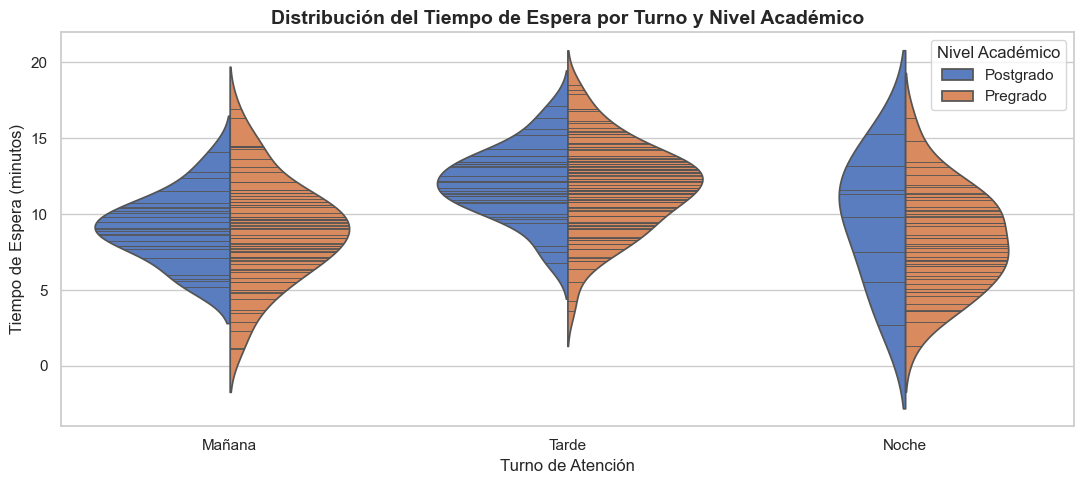

In [60]:
#Ejercicio 2
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot( 
    data=df,
    x='turno',
    y='tiempo_espera_min',
    hue='nivel_academico',
    split=True,
    inner='stick', 
    palette='muted',
    order=['Mañana', 'Tarde', 'Noche'],
    ax=ax,
    cut=2
)
ax.set_title('Distribución del Tiempo de Espera por Turno y Nivel Académico',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Turno de Atención')
ax.set_ylabel('Tiempo de Espera (minutos)')
ax.legend(title='Nivel Académico')
plt.tight_layout()
plt.show()

In [ ]:
# Pruebe cada valor de inner:
# 'box' → muestra un mini-boxplot interior
# 'quartile' → líneas en Q1, mediana y Q3
# 'point' → puntos individuales
# 'stick' → líneas verticales por cada observación
# None → violín limpio sin interior
# Pruebe también:
# cut=0 → el violín no se extiende más allá de los datos reales
# cut=2 → extensión suavizada por defecto

# Pruebas de grafico
1. Añade dos "barras" negras.
2. Añade lineral puntilineas negras.
3. Añade puntos negritos.
4. Añade lineas verticales.
5. Se ve el violín sin nada.
6. Se observa que el gráfico se 'corta' por así decirlo en los extremos.
7. El gráfico se vuelve más... "finito"? por así decirlo según lo que puedo observar.

# Analisis
1. El tiempo de espera mediano es mayor en el turno de tarde.
2. Las distribuciones presentan una leve asimetría. 
3. Tal vez pueda ser una visualización de como se distribuyen los datos, siendo dos distribuciones normales juntas comparativas.

Variables numéricas: ['semana_mes', 'gasto_total', 'tiempo_espera_min', 'calificacion_servicio', 'items_pedido', 'propina_porcentaje']

Matriz de correlación:
                       semana_mes  gasto_total  tiempo_espera_min  \
semana_mes                   1.00        -0.03              -0.07   
gasto_total                 -0.03         1.00               0.49   
tiempo_espera_min           -0.07         0.49               1.00   
calificacion_servicio        0.07        -0.16              -0.24   
items_pedido                -0.08         0.30               0.15   
propina_porcentaje           0.00         0.02              -0.04   

                       calificacion_servicio  items_pedido  propina_porcentaje  
semana_mes                              0.07         -0.08                0.00  
gasto_total                            -0.16          0.30                0.02  
tiempo_espera_min                      -0.24          0.15               -0.04  
calificacion_servicio            

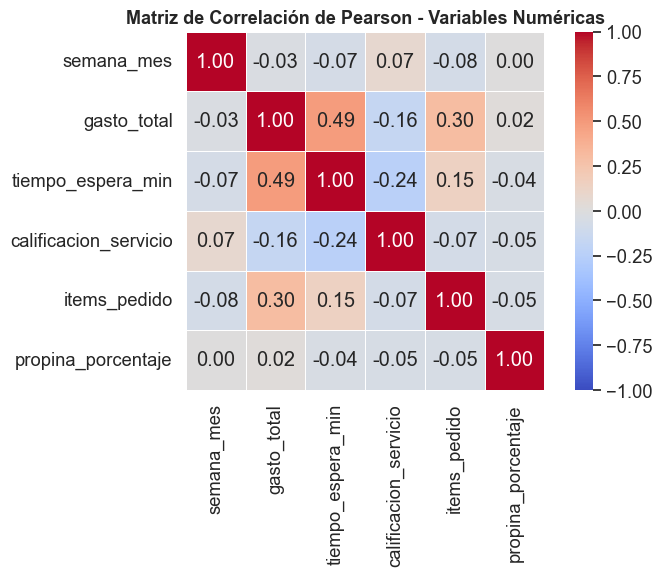

In [52]:
#Ejercicio 3
# Paso 1: Seleccionar solo columnas numéricas
num_cols = df.select_dtypes(include=np.number)
print('Variables numéricas:', list(num_cols.columns))

# Paso 2: Calcular la matriz de correlación de Pearson
corr_matrix = num_cols.corr()
print('\nMatriz de correlación:')
print(corr_matrix.round(2))

# Paso 3: Visualizar como heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap( 
    data=corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax
)
ax.set_title('Matriz de Correlación de Pearson - Variables Numéricas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Analisis
1. Por lo observable 0.49 como tal entre tiempo de espera min y gasto total. Debido a un mayor gasto pudiendo ser un pedido más grande.
2. Lo observable una correlación marcada de -0.24 entre calificacion_servicio y tiempo_espera. Se intuye que entre más espera más baja la calificacion y el descontento del cliente.
3. Es propina_porcentaje con un -0.05 a 0.01 en correlación, puede ser que dependa de la cultura incluso si en dejar propina o no dependiendo de la persona que quiera dejarle.

C:\Users\thewe\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\thewe\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\thewe\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\thewe\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

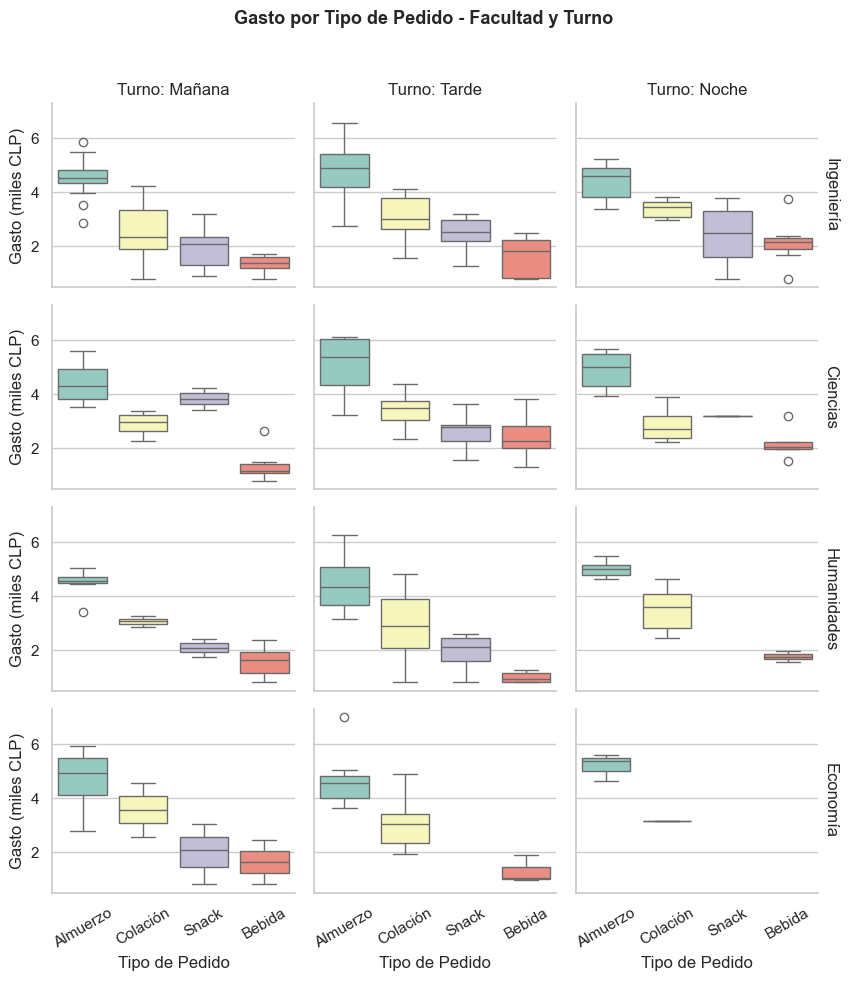

In [53]:
#Ejercicio 4
sns.set_theme(style='whitegrid', font_scale=1.0)
g = sns.FacetGrid( 
    data=df,
    col='turno',
    row='facultad',
    col_order=['Mañana', 'Tarde', 'Noche'],
    row_order=['Ingeniería', 'Ciencias', 'Humanidades', 'Economía'],
    height=2.4,
    aspect=1.2,
    margin_titles=True
)
g.map_dataframe(
    sns.boxplot,
    x='tipo_pedido',
    y='gasto_total',
    palette='Set3',
    order=['Almuerzo', 'Colación', 'Snack', 'Bebida']
)
g.set_axis_labels('Tipo de Pedido', 'Gasto (miles CLP)')
g.set_titles(col_template='Turno: {col_name}', row_template='{row_name}')
g.figure.suptitle('Gasto por Tipo de Pedido - Facultad y Turno',
                  y=1.02, fontsize=13, fontweight='bold')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
g.savefig('act4_facetgrid.png', dpi=300, bbox_inches='tight')
plt.show()

# Analisis E4
1. El mayor gasto en categoría almuerzo se registra en tarde - ciencias , y el menor gasto mediano en mañana ciencias.
2. Tienen sus respectivas diferencias de hecho, pero si hablamos de un patrón/comportamiento si parecen similares. Entre mañana y tarde de ingeniería y ciencias
3. Creo que automatiza la separación de datos además de implementar la creación de subfiguras en base a las variables que se le otorgan. 

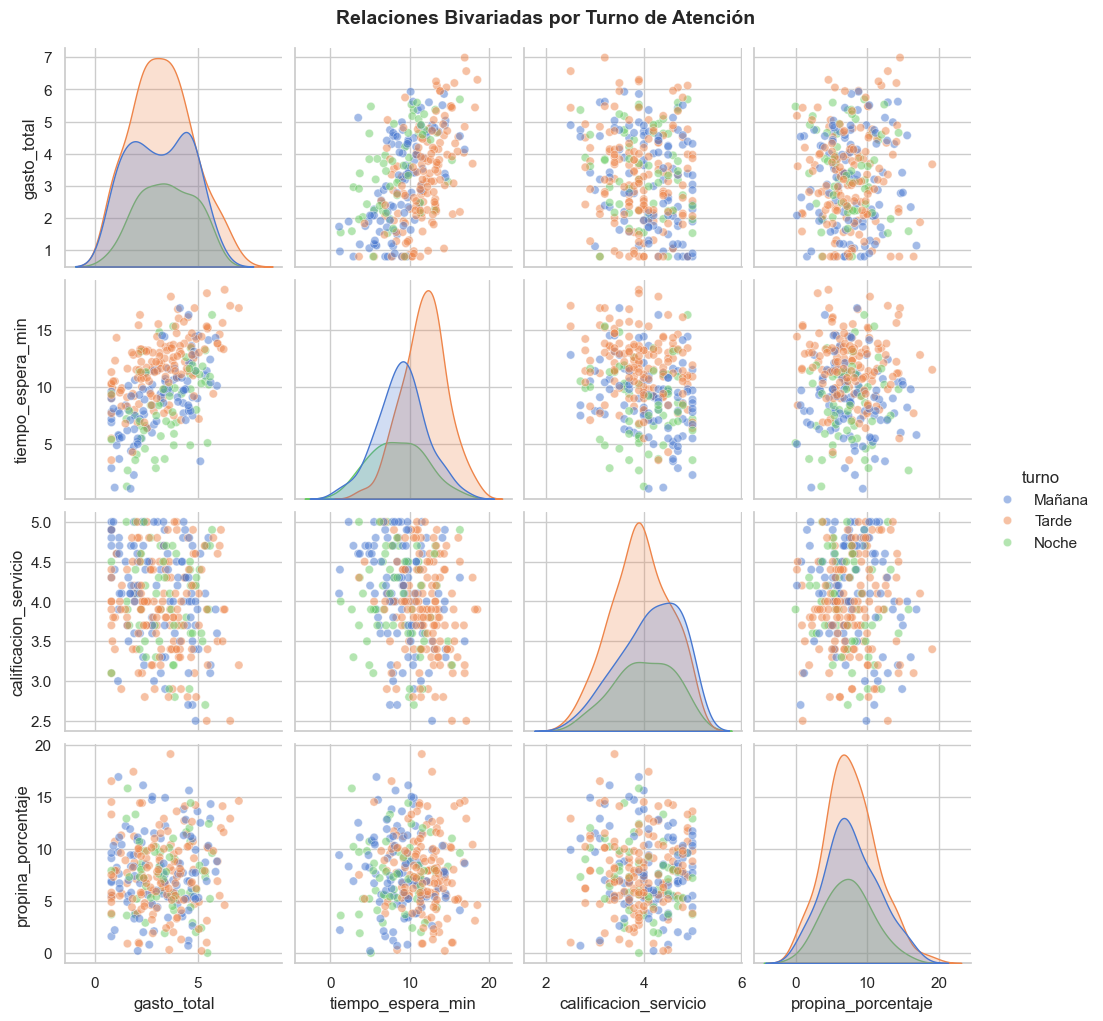

In [61]:
#Ejercicio5
# Seleccionar variables numéricas de interés
vars_plot = ['gasto_total', 'tiempo_espera_min',
'calificacion_servicio', 'propina_porcentaje']
g = sns.pairplot(
df[vars_plot + ['turno']],
hue='turno',
hue_order=['Mañana', 'Tarde', 'Noche'],
diag_kind='kde',
plot_kws={'alpha': 0.5},
palette='muted'
)
g.figure.suptitle(
'Relaciones Bivariadas por Turno de Atención',
y=1.02, fontsize=14, fontweight='bold'
)
g.savefig('desafio_pairplot.svg', bbox_inches='tight') # SVG = calidad vectorial
plt.show()

# Ejercicio 5 Analisis mio

1. El código me entregó una imagen vectorial en formato svg, que al hacerle zoom no pierde absolutamente nada de calidad. Siendo mejor que la captura 